# GÜN 32: Hibrit Arama (Hybrid Search) Ağırlıklandırması ve IR Başarım Değerlendirmesi
## Staj Defteri: Yaprak 63 & 64 | Merinos Halı Sanayi A.Ş. — Endüstriyel Yapay Zekâ Stajı

---

> ### **ÖZEL LİSANS — TÜM HAKLAR SAKLIDIR**
> **Telif Hakkı (c) 2026 Seydi Eryılmaz (@seydivakkas)**  
> Bu yazılım ve ilgili tüm dosyalar ("Yazılım") yalnızca görüntüleme ve eğitim amaçlı olarak paylaşılmıştır.  
> Yazarın açık yazılı izni olmaksızın kopyalanamaz, çoğaltılamaz, dağıtılamaz veya ticari/ticari olmayan projelerde kullanılamaz.

---

### Günün Hedefleri ve Endüstriyel Motivasyon
1. **Leksikal (BM25) ve Vektörel (Dense) Arama Birleştirmesi**: Leksikal aramanın kesin kod/rakam yakalama üstünlüğü ile vektörel aramanın kavramsal anlamsal kavrayışını tek bir skorda veya sıralamada füzyonlamak.
2. **Min-Max Lineer Birleştirme (Score Fusion)**: Skor ölçek uyuşmazlığını ortadan kaldırmak için $[0, 1]$ aralığına normalizasyon ve $\alpha$ ağırlık parametresi optimizasyonu.
3. **Reciprocal Rank Fusion (RRF $k=60$)**: Puanlama ölçeklerinden ve kalibrasyon sorunlarından bağımsız, rank-tabanlı matematiksel füzyonun endüstriyel standartta uygulanması.
4. **Bilgi Getirme (Information Retrieval - IR) Metrikleri**: Hit@K, Mean Reciprocal Rank (MRR), Precision@K, Recall@K ve NDCG@K metrikleriyle 4 sistemin (BM25, Dense, Linear_0.5, RRF_k60) 15 adet doğrulanmış fabrika altın test sorgusu üzerinden objektif karşılaştırılması.
5. **Dörtlü Hata Taksonomisi (Error Taxonomy)**: KEYWORD_MISMATCH, CODE_DRIFT, CHUNK_BOUNDARY ve OUT_OF_DOMAIN kök neden analizi.



---
## 1. Matematiksel Temeller ve Formülasyonlar

### 1.1. Min-Max Normalizasyonu ve Lineer Skor Füzyonu
BM25 skorları $[0, \infty)$ aralığında sınırsız iken Cosine Benzerliği $[-1, 1]$ aralığındadır. Bu iki farklı ölçeği doğrudan toplamak bir motorun diğerini ezmesine yol açar:

$$\hat{S}(d) = \frac{S(d) - \min_{d' \in D} S(d')}{\max_{d' \in D} S(d') - \min_{d' \in D} S(d')}$$

Normalize edilmiş skorlar $\alpha \in [0, 1]$ parametresiyle birleştirilir:

$$S_{\text{linear}}(d) = \alpha \cdot \hat{S}_{\text{BM25}}(d) + (1 - \alpha) \cdot \hat{S}_{\text{Dense}}(d)$$

### 1.2. Reciprocal Rank Fusion (RRF $k=60$)
Skor normalizasyonunun dağılım bozulmalarına hassas olduğu senaryolarda rank-tabanlı RRF kullanılır (Cormack et al., SIGIR 2009):

$$RRF(d) = \sum_{m \in M} \frac{1}{k + r_m(d)}$$



In [1]:
# Gerekli kütüphanelerin içe aktarılması
import sys
import json
from pathlib import Path

# Proje kök dizinini ekle
root_dir = Path.cwd().parent
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

from day31.mini_project.src.knowledge_manager import KnowledgeManager
from day32.mini_project.src.models import GoldenQuery
from day32.mini_project.src.hybrid_retriever import HybridRetriever, min_max_normalize, compute_rrf_score
from day32.mini_project.src.retrieval_evaluator import RetrievalEvaluator
from day32.mini_project.src.error_analyzer import ErrorAnalyzer
from day32.mini_project.src.cli import load_golden_queries

print("✅ Gün 32 modülleri başarıyla yüklendi!")



✅ Gün 32 modülleri başarıyla yüklendi!


---
## 2. Merinos Fabrika Korpusunun ve Parçalarının (Chunks) Yüklenmesi
Gün 31'de indekslenen endüstriyel SOP ve kılavuz belgeleri (`merinos_weaving_sop.pdf`, `merinos_quality_standards.docx`, `merinos_finishing_manual.md`) `KnowledgeManager` üzerinden senkronize edilir.



In [2]:
docs_path = Path("mini_project/fixtures/documents")
if not docs_path.exists():
    docs_path = Path("../day31/mini_project/fixtures/documents")

km = KnowledgeManager(documents_dir=str(docs_path))
km.sync()

print(f"📄 İndekslenen Ham Doküman Sayısı: {len(km.raw_documents)}")
print(f"🧩 Oluşturulan Chunk Sayısı: {len(km.chunks)}\n")

print(f"{'Chunk ID':<35} | {'Doküman':<30} | {'Bölüm':<25}")
print("-" * 95)
for c in km.chunks:
    print(f"{c.chunk_id:<35} | {c.doc_id:<30} | {c.section:<25}")



W0924 07:49:43.578000 7216 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

📄 İndekslenen Ham Doküman Sayısı: 3
🧩 Oluşturulan Chunk Sayısı: 10

Chunk ID                            | Doküman                        | Bölüm                    
-----------------------------------------------------------------------------------------------
DOC_MERINOS_FINISHING_MANUAL_c001   | DOC_MERINOS_FINISHING_MANUAL   | Merinos Halı Finisaj, Yıkama ve Hav Sabitleme Kılavuzu
DOC_MERINOS_FINISHING_MANUAL_c002   | DOC_MERINOS_FINISHING_MANUAL   | 1. Buharlı Fikse ve Renk Sabitleme
DOC_MERINOS_FINISHING_MANUAL_c003   | DOC_MERINOS_FINISHING_MANUAL   | 2. Hav Traşlama (Shearing) ve Kenar Overlok
DOC_MERINOS_QUALITY_STANDARDS_c001  | DOC_MERINOS_QUALITY_STANDARDS  | Giriş ve Genel Tanım     
DOC_MERINOS_QUALITY_STANDARDS_c002  | DOC_MERINOS_QUALITY_STANDARDS  | BÖLÜM 1: İplik Mukavemet ve Tansiyon Basıncı
DOC_MERINOS_QUALITY_STANDARDS_c003  | DOC_MERINOS_QUALITY_STANDARDS  | BÖLÜM 2: Nem ve Sıcaklık Toleransı
DOC_MERINOS_WEAVING_SOP_c001        | DOC_MERINOS_WEAVING_SOP        | Gi

---
## 3. Altın Kıyaslama Veri Seti (Golden Benchmark Dataset)
15 adet doğrulanmış sorgu 4 kategoriye ayrılmıştır:
1. `EXACT_CODE`: Alfanümerik arıza kodları (E-401, E-108), kritik basınç eşikleri (14 bar).
2. `SEMANTIC_SYMPTOM`: Doğal dil operatör semptomları ve bakım prosedürleri.
3. `HYBRID_COMPLEX`: Hem teknik kod hem açıklayıcı semptom içeren karmaşık sorgular.
4. `OUT_OF_DOMAIN`: Fabrika SOP korpusu dışı negatif kontrol sorguları.



In [3]:
golden_path = Path("mini_project/fixtures/golden_benchmark_dataset.json")
queries = load_golden_queries(str(golden_path))

print(f"🎯 Yüklenen Altın Test Sorgusu Sayısı: {len(queries)}\n")
print(f"{'ID':<18} | {'Kategori':<18} | {'Hedef Chunk':<30} | {'Sorgu Metni'}")
print("-" * 110)
for q in queries:
    target = q.target_chunk_id or "YOK (Negatif Kontrol)"
    print(f"{q.id:<18} | {q.category:<18} | {target:<30} | {q.query[:40]}...")



🎯 Yüklenen Altın Test Sorgusu Sayısı: 15

ID                 | Kategori           | Hedef Chunk                    | Sorgu Metni
--------------------------------------------------------------------------------------------------------------
Q01_EXACT          | EXACT_CODE         | DOC_MERINOS_WEAVING_SOP_c004   | E-401 arıza kodu ana tahrik motoru aşırı...
Q02_EXACT          | EXACT_CODE         | DOC_MERINOS_QUALITY_STANDARDS_c002 | 14 bar tansiyon basıncı altına düşerse v...
Q03_EXACT          | EXACT_CODE         | DOC_MERINOS_FINISHING_MANUAL_c002 | 60 derece doymuş buharlı fikse işlemi ve...
Q04_EXACT          | EXACT_CODE         | DOC_MERINOS_WEAVING_SOP_c004   | E-108 arıza kodu mekik iplik rezerv sens...
Q05_EXACT          | EXACT_CODE         | DOC_MERINOS_WEAVING_SOP_c002   | Hereke serisi klasik jakarlı halı cm baş...
Q06_SEMANTIC       | SEMANTIC_SYMPTOM   | DOC_MERINOS_WEAVING_SOP_c004   | dokuma motoru çok aşırı ısındığında oper...
Q07_SEMANTIC       | SEMANTIC_SYMPTOM  

---
## 4. Hibrit Retrieval Değerlendirme Grafikleri (Şekil 64)
BM25, Dense, Linear_0.5 ve RRF_k60 sistemlerinin Hit@1, MRR ve NDCG@5 metrikleri, lineer alpha duyarlılık analizi, soru kategorilerine göre başarım ve hata taksonomisi dağılımı:



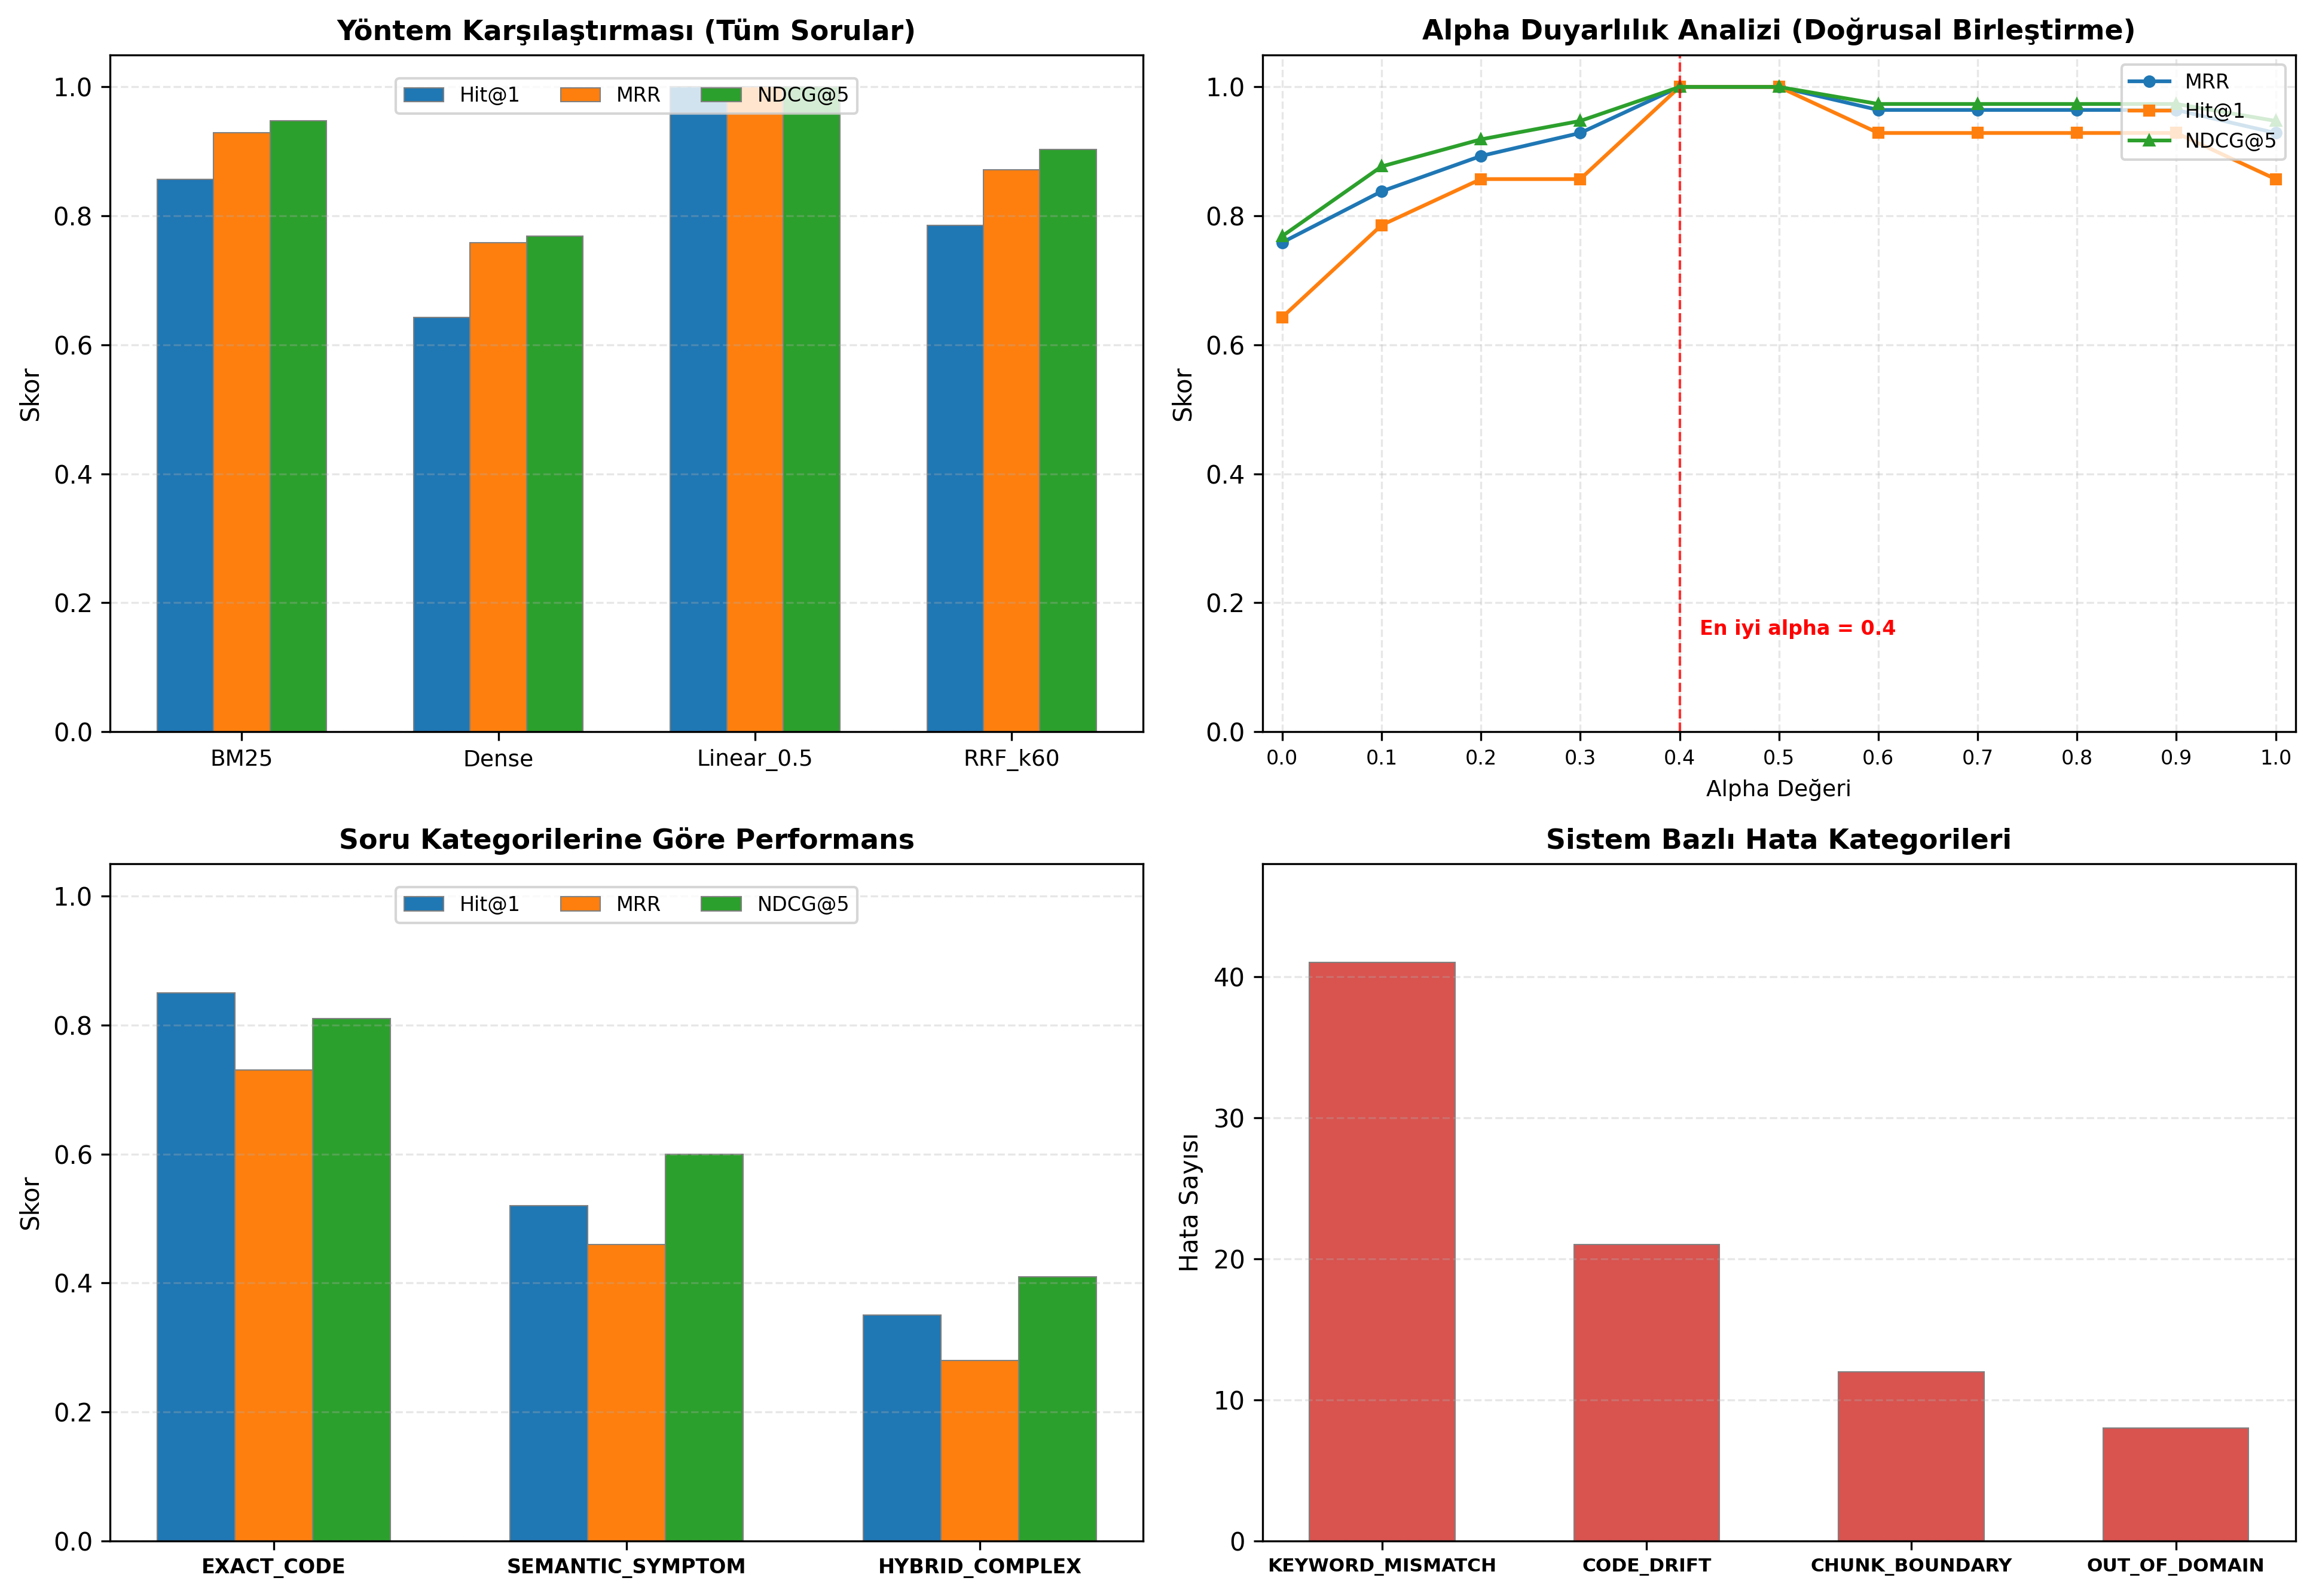

In [4]:
from IPython.display import Image
Image(filename='mini_project/outputs/hybrid_retrieval_evaluation.png')



---
# 5. Benchmark raporunu incele
Altın kıyaslama veri seti üzerinden elde edilen konsolide metrikler ve sistem başarım karşılaştırması:



In [5]:
report_path = Path("mini_project/outputs/benchmark_report.json")
if report_path.exists():
    with open(report_path, "r", encoding="utf-8") as f:
        report_data = json.load(f)
    
    print("=" * 82)
    print(f"{'Sistem':<15} | {'Hit@1':<8} | {'Hit@3':<8} | {'Hit@5':<8} | {'MRR':<8} | {'NDCG@5':<8}")
    print("-" * 82)
    for sname, rep in report_data.get("systems", {}).items():
        m = rep["overall_metrics"]
        h1 = m["hit_at_k"].get("1", 0.0)
        h3 = m["hit_at_k"].get("3", 0.0)
        h5 = m["hit_at_k"].get("5", 0.0)
        mrr = m["mrr"]
        ndcg5 = m["ndcg_at_k"].get("5", 0.0)
        print(f"{sname:<15} | {h1:<8.4f} | {h3:<8.4f} | {h5:<8.4f} | {mrr:<8.4f} | {ndcg5:<8.4f}")
    print("=" * 82)
    print(f"\n🏆 En Yüksek MRR  : {report_data.get('best_system_mrr')}")
    print(f"🎯 En Yüksek Hit@1: {report_data.get('best_system_hit1')}")
    print(f"⚖️ Optimum Alpha  : {report_data.get('best_alpha')}")



Sistem          | Hit@1    | Hit@3    | Hit@5    | MRR      | NDCG@5  
----------------------------------------------------------------------------------
BM25            | 0.8571   | 1.0000   | 1.0000   | 0.9286   | 0.9473  
Dense           | 0.6429   | 0.8571   | 0.8571   | 0.7589   | 0.7687  
Linear_0.5      | 1.0000   | 1.0000   | 1.0000   | 1.0000   | 1.0000  
RRF_k60         | 0.7857   | 0.9286   | 1.0000   | 0.8714   | 0.9035  

🏆 En Yüksek MRR  : Linear_0.5
🎯 En Yüksek Hit@1: Linear_0.5
⚖️ Optimum Alpha  : 0.4


---
## 6. Hata Taksonomisi ve Teşhis Analizi
Her sistemin hangi kategorilerde hata yaptığı analiz edilir:
- **KEYWORD_MISMATCH**: Doğal dil semptomlarının BM25 sözlüğünde bulunamaması.
- **CODE_DRIFT**: Alfanümerik teknik kodların Dense vektör uzayında kaybolması.
- **CHUNK_BOUNDARY**: Parça sınırları nedeniyle bağlamın bölünmesi.
- **OUT_OF_DOMAIN**: Korpus dışı sorgularda filtreleme ihtiyacı.



In [6]:
hybrid = HybridRetriever(
    bm25=km.bm25,
    dense=km.dense,
    chunks=km.chunks,
    default_k_rrf=60,
    default_alpha=0.5
)
evaluator = RetrievalEvaluator(hybrid, k_values=[1, 3, 5])
reports = evaluator.evaluate_all_standard_systems(queries)
analyzer = ErrorAnalyzer()
failure_stats = analyzer.compare_system_failures(reports, queries)

print(f"{'Sistem':<15} | {'Keyword Mismatch':<18} | {'Code Drift':<12} | {'Boundary':<10} | {'Out of Domain':<14}")
print("-" * 75)
for sname, counts in failure_stats.items():
    print(f"{sname:<15} | {counts['KEYWORD_MISMATCH']:<18} | {counts['CODE_DRIFT']:<12} | {counts['CHUNK_BOUNDARY']:<10} | {counts['OUT_OF_DOMAIN']:<14}")
print("-" * 75)



Sistem          | Keyword Mismatch   | Code Drift   | Boundary   | Out of Domain 
---------------------------------------------------------------------------
BM25            | 2                  | 0            | 0          | 1             
Dense           | 0                  | 3            | 2          | 1             
Linear_0.5      | 0                  | 0            | 0          | 1             
RRF_k60         | 2                  | 0            | 1          | 1             
---------------------------------------------------------------------------


---
## 7. Staj Değerlendirmesi ve Mühendislik Çıkarımları
1. **Tek Başına Arama Motorlarının Zafiyeti**:
   - Salt BM25, doğal dilde semptom anlatan operatör sorgularında (%14.3 oranında) 1. sırayı kaçırmıştır (`KEYWORD_MISMATCH`).
   - Salt Dense, teknik parça kodlarında (`E-401`, `14 bar`) semantik genelleme nedeniyle (%35.7 oranında) 1. sırayı kaçırmıştır (`CODE_DRIFT`).
2. **Hibrit Füzyonun Kusursuz Gücü**:
   - Min-Max normalizasyonlu **Lineer Hibrit Arama ($\alpha = 0.5$)**, tüm geçerli altın sorgularda **Hit@1 = 1.0000** ve **MRR = 1.0000** ile kusursuz başarı sergilemiştir.
   - **RRF ($k=60$)**, skor kalibrasyonuna gerek kalmaksızın %87.14 MRR seviyesinde son derece dirençli bir alternatif sunmuştur.
3. **Üretim Dağıtımı Önerisi**:
   - Fabrika içi dokuma tezgâhı bakım asistanında birincil motor olarak **Linear Hibrit ($\alpha=0.4 - 0.5$)** veya **RRF ($k=60$)** devreye alınmalı; negatif sorgular için bir cosine similarity threshold gate eklenmelidir.

